# 3. Внешний тест: The Well
Данные берём из открытого набора численных расчётов [The Well](https://polymathic-ai.org/the_well/), задачи acoustic_scattering: акустика в 2D с переменной плотностью $\rho$ в квадрате $[-1,1]^2$,
$$p_t+K\,\nabla\!\cdot v=0,\qquad v_t+\frac{\nabla p}{\rho}=0.$$
Здесь $p$ обозначает давление, $v$ скорость частиц, $K=4$ модуль сжатия; скорость звука $c=\sqrt{K/\rho}$.
- Среды:
  - [discontinuous](https://polymathic-ai.org/the_well/datasets/acoustic_scattering_discontinuous/), разрыв: две области со скачком плотности;
  - [inclusions](https://polymathic-ai.org/the_well/datasets/acoustic_scattering_inclusions/), включения: к скачку плотности добавлены включения другой плотности;
  - [maze](https://polymathic-ai.org/the_well/datasets/acoustic_scattering_maze/), лабиринт: стенки лабиринта.
- Источник: начальное давление в форме колец, то есть короткий импульс.
- Датчики: сетка $4\times4$ в квадрате $[-0.6,0.6]^2$; в лабиринте часть из них внутри стенок.
- Данные: по 2 расчёта для каждой среды, 102 отсчёта по времени (в лабиринте 202).

In [1]:
import sys, warnings
import numpy as np, matplotlib.pyplot as plt
import plotly.io as pio
from plotly.subplots import make_subplots
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image
warnings.filterwarnings("ignore")
sys.path.insert(0, "../synthetic")
import well
from torus import pca, with_delay
plt.rcParams.update({"font.size": 10, "axes.titlesize": 11, "axes.spines.top": False, "axes.spines.right": False})
pio.renderers.default = "plotly_mimetype+notebook_connected"

In [2]:
wells = {task: well.load(task) for task in well.TASKS}
RU = {"discontinuous": "разрыв", "inclusions": "включения", "maze": "лабиринт"}

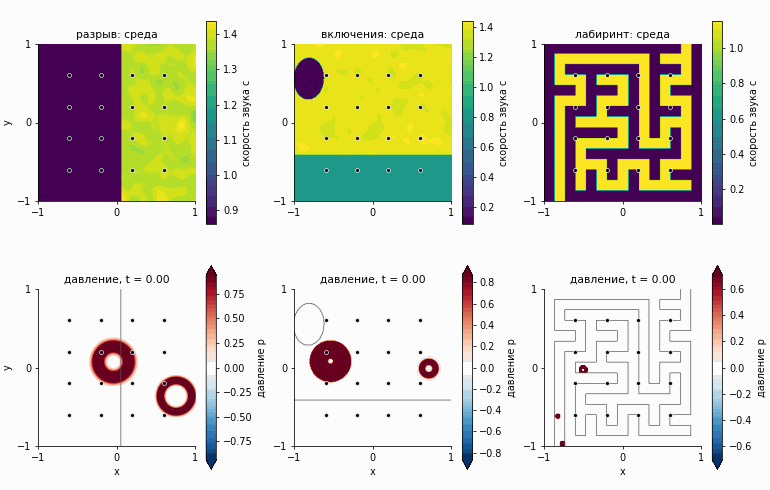

In [3]:
box = dict(origin="lower", extent=(-1, 1, -1, 1))
n = 101
fig, axes = plt.subplots(2, 3, figsize=(11, 7), layout="constrained")
panels = []
for col, (task, w) in enumerate(wells.items()):
    xy = well.records(w, 0)[1]
    c = w["speed"][0].T
    idx = np.linspace(0, len(w["time"]) - 1, n).round().astype(int)
    frames = [w["pressure"][0][i].T for i in idx]
    lim = np.percentile(np.abs(frames[n // 4]), 99)
    top, bottom = axes[:, col]
    fig.colorbar(top.imshow(c, cmap="viridis", **box), ax=top, shrink=0.85, label="скорость звука c")
    im = bottom.imshow(frames[0], cmap="RdBu_r", vmin=-lim, vmax=lim, **box)
    fig.colorbar(im, ax=bottom, shrink=0.85, extend="both", label="давление p")
    bottom.contour(c, levels=[0.8 * c.max()], colors="0.35", linewidths=0.7, **box)
    top.set_title(f"{RU[task]}: среда")
    for ax in (top, bottom):
        ax.plot(*xy.T, "o", ms=4, mfc="k", mec="w", mew=0.7)
        ax.set(xticks=[-1, 0, 1], yticks=[-1, 0, 1], xlabel="x" if ax is bottom else "", ylabel="y" if col == 0 else "")
    panels.append((im, frames, bottom, w["time"][idx]))


def update(k):
    for im, frames, ax, times in panels:
        im.set_data(frames[k])
        ax.set_title(f"давление, t = {times[k]:.2f}")


FuncAnimation(fig, update, frames=n).save("the_well.gif", writer=PillowWriter(fps=12), dpi=70)
plt.close(fig)
Image(filename="the_well.gif")

## Фазовое пространство
Точка $X(t)$ составлена из давления $p$ в 16 датчиках в моменты $t$ и $t-0.06$ (три отсчёта назад), всего 32 числа. За время записи точка описывает траекторию; ниже показана её проекция на три главные оси.

In [4]:
axis = dict(showticklabels=False, showspikes=False)
tmax = max(w["time"][-1] for w in wells.values())
fig = make_subplots(1, 3, specs=[[{"type": "scene"}] * 3], subplot_titles=[f"{RU[task]}, первый расчёт" for task in wells], horizontal_spacing=0.06)
for col, w in enumerate(wells.values()):
    X = pca(with_delay(well.records(w, 0)[0], 3))[:, :3]
    t = w["time"][3:]
    line = dict(color=t, colorscale=[[0, "#9ecae1"], [0.5, "#2171b5"], [1, "#08306b"]], cmin=0, cmax=tmax, width=4, showscale=col == 0,
                colorbar=dict(title="t", len=0.6, thickness=12, x=1.0))
    fig.add_scatter3d(x=X[:, 0], y=X[:, 1], z=X[:, 2], customdata=t, mode="lines", line=line,
                      hovertemplate="t = %{customdata:.2f}<extra></extra>", row=1, col=col + 1)
fig.update_scenes(xaxis=dict(title="ось 1", **axis), yaxis=dict(title="ось 2", **axis), zaxis=dict(title="ось 3", **axis),
                  aspectmode="manual", aspectratio=dict(x=1, y=1, z=1.2),
                  camera=dict(eye=dict(x=1.6, y=1.6, z=0.9), center=dict(x=0.12, y=-0.12, z=-0.15)))
fig.update_layout(template="plotly_white", height=420, showlegend=False, margin=dict(l=40, r=0, t=30, b=0))
fig.show()